
# Predict pCR article Plots

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/naomifridman/BreastDCEDL/blob/main/plot_pCR_article_results.ipynb)

In [7]:

from PIL import Image
import requests
import argparse
import datetime
import json
import numpy as np
import os
import time
from pathlib import Path
from sklearn.metrics import classification_report,auc,roc_auc_score,recall_score,precision_score
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
#import seaborn as sns

In [8]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# Results ploting

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

viridis_12 = plt.cm.viridis(np.linspace(0.8, 0.2, 12))
GROUP_COLORS = [viridis_12[0], viridis_12[11], viridis_12[5]]   # green, purple, teal
cmap_overall = LinearSegmentedColormap.from_list('cm_overall', ['white', 'dimgrey', 'black'])
cmaps_group  = [LinearSegmentedColormap.from_list(f'cm_{k}', ['white', GROUP_COLORS[k]]) for k in range(3)]
THR = 0.5

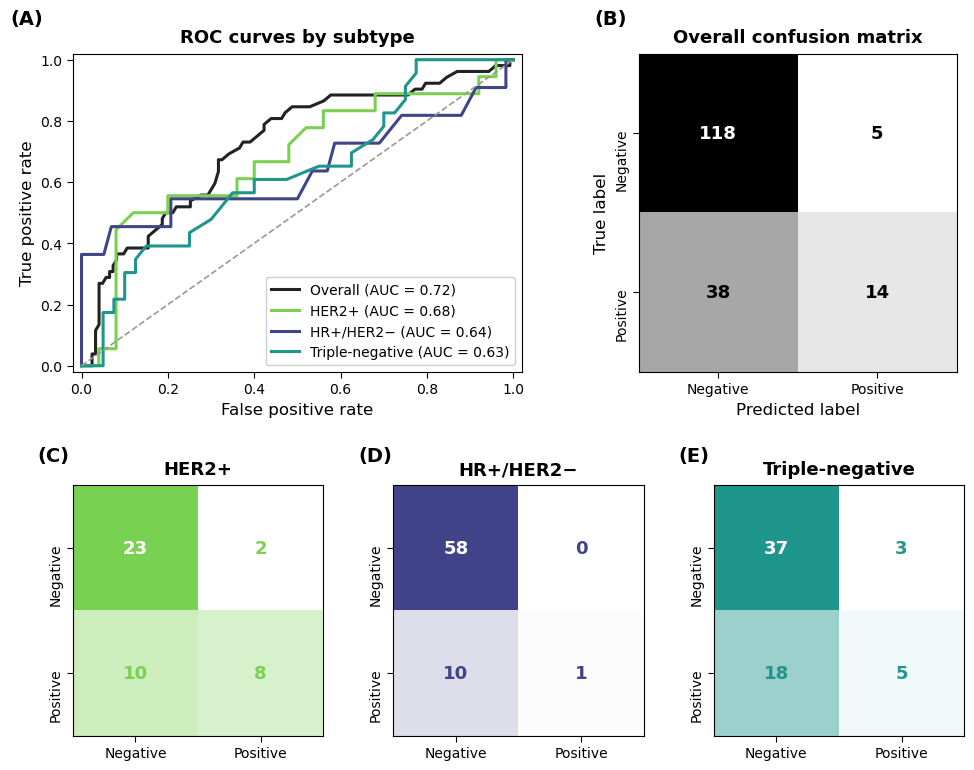

Saved: fig_4_subtype_academic.png (299,966 bytes)
Saved: fig_4_subtype_academic.pdf (28,093 bytes)


In [87]:
df=pd.read_csv('C:\\Users\\naomi\\Downloads\\breast_mri\\code_to_follow\\df_breastdcedl_pcr.csv')
#df.info()import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# Global style for publication
# -----------------------------
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# Input data
# -----------------------------
df_test = df[df['test'] == 1.0].copy()
df_test['pCR'] = pd.to_numeric(df_test['pCR'], errors='coerce')
df_test['pred_pcr_vnew'] = pd.to_numeric(df_test['pred_pcr_vnew'], errors='coerce')
df_test = df_test.dropna(subset=['pCR', 'pred_pcr_vnew'])

y = df_test['pCR'].values
p = df_test['pred_pcr_vnew'].values

# -----------------------------
# Color definitions
# Replace these if not defined
# -----------------------------
# Example fallback colors if GROUP_COLORS etc. are not defined:
if 'GROUP_COLORS' not in globals():
    GROUP_COLORS = ['#1b9e77', '#d95f02', '#7570b3']

if 'cmap_overall' not in globals():
    cmap_overall = plt.cm.Greys

if 'cmaps_group' not in globals():
    cmaps_group = [plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]

# -----------------------------
# Panels
# -----------------------------
panels = [
    ('__all__',      'Overall',        '#222222',       cmap_overall),
    ('HER2pos',      'HER2+',          GROUP_COLORS[0], cmaps_group[0]),
    ('HRposHER2neg', 'HR+/HER2−',      GROUP_COLORS[1], cmaps_group[1]),
    ('TripleNeg',    'Triple-negative',GROUP_COLORS[2], cmaps_group[2]),
]

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(11.5, 9.2), constrained_layout=False)
outer = fig.add_gridspec(
    2, 1,
    height_ratios=[1.05, 1.0],
    hspace=0.28
)

top = outer[0].subgridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.28)
bottom = outer[1].subgridspec(1, 3, wspace=0.28)

ax_roc = fig.add_subplot(top[0, 0])
ax_ov  = fig.add_subplot(top[0, 1])
ax_cm1 = fig.add_subplot(bottom[0, 0])
ax_cm2 = fig.add_subplot(bottom[0, 1])
ax_cm3 = fig.add_subplot(bottom[0, 2])

cm_axes = [ax_ov, ax_cm1, ax_cm2, ax_cm3]

# -----------------------------
# Helper: panel label
# -----------------------------
def add_panel_label(ax, label):
    ax.text(
        -0.14, 1.08, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='bottom',
        ha='left'
    )

# -----------------------------
# Plot ROC + confusion matrices
# -----------------------------
roc_labels = []
ok = True

for j, (key, name, color, cmap) in enumerate(panels):
    mask = np.ones(len(df_test), dtype=bool) if key == '__all__' else (df_test['HR_HER2_STATUS'].values == key)
    yj = y[mask]
    pj = p[mask]

    if mask.sum() == 0 or len(np.unique(yj)) < 2:
        print(f"Skipping {name}: empty group or single class.")
        ok = False
        continue

    # ROC
    fpr, tpr, _ = roc_curve(yj, pj)
    roc_auc = auc(fpr, tpr)
    roc_labels.append((name, roc_auc, color))
    ax_roc.plot(fpr, tpr, color=color, lw=2.2, label=f"{name} (AUC = {roc_auc:.2f})")

    # Confusion matrix
    ax = cm_axes[j]
    yhat = (pj >= THR).astype(int)
    cm = confusion_matrix(yj, yhat)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(
        ax=ax,
        cmap=cmap,
        colorbar=False,
        values_format='d'
    )

    # Make annotation text cleaner
    for txt in ax.texts:
        txt.set_fontsize(13)
        txt.set_fontweight('semibold')

    # Titles
    if key == '__all__':
        ax.set_title("Overall confusion matrix", pad=8, fontweight='bold')
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
    else:
        ax.set_title(name, pad=8, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Rotate ticks: x horizontal, y vertical for ALL CMs
    ax.tick_params(axis='x', labelrotation=0)
    ax.tick_params(axis='y', labelrotation=90)

    ax.grid(False)
    ax.set_aspect('equal')

'''# -----------------------------
# Format ROC panel
# -----------------------------
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='0.6', lw=1.2)
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1)
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curves by subtype", pad=8, fontweight='bold')
ax_roc.legend(loc='lower right', frameon=True, framealpha=0.95)
ax_roc.grid(False)
ax_roc.set_aspect('auto')'''

# -----------------------------
# Format ROC panel
# -----------------------------
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='0.6', lw=1.2)

# Add a small margin so curves at 0 or 1 are fully visible
eps = 0.02  # you can adjust this if you like
ax_roc.set_xlim(-eps, 1 + eps)
ax_roc.set_ylim(-eps, 1 + eps)

ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curves by subtype", pad=8, fontweight='bold')
ax_roc.legend(loc='lower right', frameon=True, framealpha=0.95)
ax_roc.grid(False)
ax_roc.set_aspect('auto')

# -----------------------------
# Panel labels
# -----------------------------
add_panel_label(ax_roc, "(A)")
add_panel_label(ax_ov,  "(B)")
add_panel_label(ax_cm1, "(C)")
add_panel_label(ax_cm2, "(D)")
add_panel_label(ax_cm3, "(E)")

# -----------------------------
# Optional overall figure title
# -----------------------------
#fig.suptitle("Subtype-specific ROC curves and confusion matrices for pCR prediction",
#             y=0.98, fontweight='bold')

# -----------------------------
# Save
# -----------------------------
out_png = "fig_4_subtype_academic.png"
out_pdf = "fig_4_subtype_academic.pdf"

fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(f"Saved: {out_png} ({os.path.getsize(out_png):,} bytes)")
print(f"Saved: {out_pdf} ({os.path.getsize(out_pdf):,} bytes)")

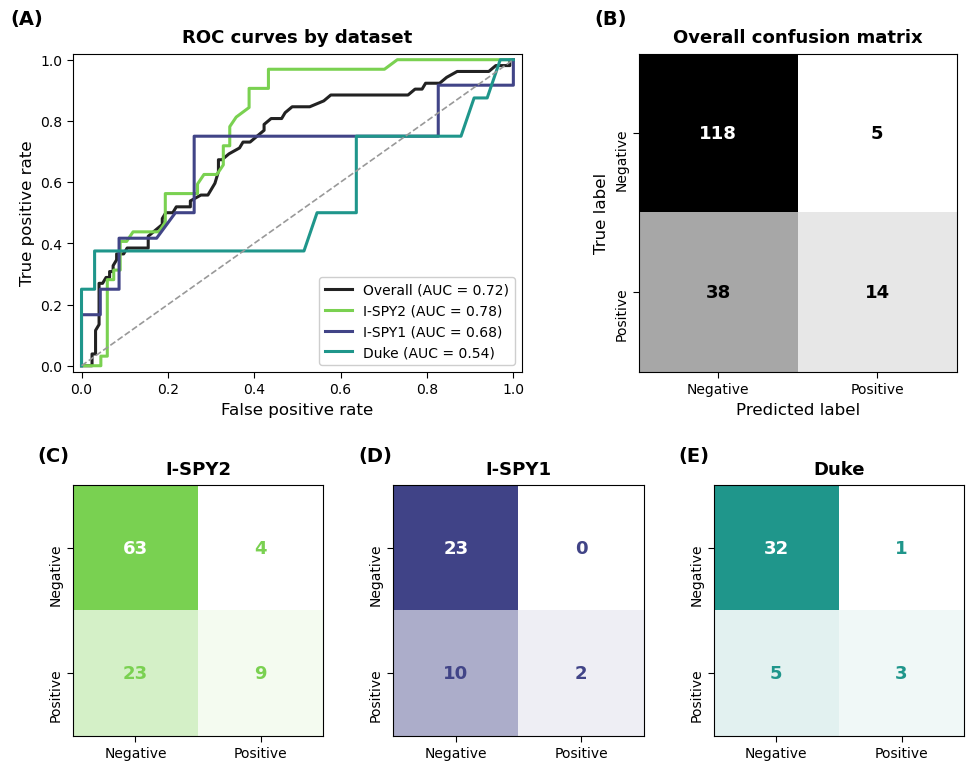

Saved: fig_5_dataset_academic.png (281,394 bytes)
Saved: fig_5_dataset_academic.pdf (30,631 bytes)


In [92]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Colors & colormaps (same as subtype figure)
viridis_12 = plt.cm.viridis(np.linspace(0.8, 0.2, 12))
GROUP_COLORS = [viridis_12[0], viridis_12[11], viridis_12[5]]   # green, purple, teal
cmap_overall = LinearSegmentedColormap.from_list('cm_overall', ['white', 'dimgrey', 'black'])
cmaps_group  = [LinearSegmentedColormap.from_list(f'cm_{k}', ['white', GROUP_COLORS[k]]) for k in range(3)]
THR = 0.5

# Global style (same as before)
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Data
df_test = df[df['test'] == 1.0].copy()
df_test['pCR'] = pd.to_numeric(df_test['pCR'], errors='coerce')
df_test['pred_pcr_vnew'] = pd.to_numeric(df_test['pred_pcr_vnew'], errors='coerce')
df_test = df_test.dropna(subset=['pCR', 'pred_pcr_vnew', 'dataset'])

y = df_test['pCR'].values
p = df_test['pred_pcr_vnew'].values

# Panels: overall + datasets, reusing GROUP_COLORS and cmaps_group
panels = [
    ('__all__', 'Overall', '#222222', cmap_overall),
    ('spy2',    'I-SPY2',  GROUP_COLORS[0], cmaps_group[0]),
    ('spy1',    'I-SPY1',  GROUP_COLORS[1], cmaps_group[1]),
    ('duke',    'Duke',    GROUP_COLORS[2], cmaps_group[2]),
]

# Layout (identical to subtype fig)
fig = plt.figure(figsize=(11.5, 9.2), constrained_layout=False)
outer = fig.add_gridspec(2, 1, height_ratios=[1.05, 1.0], hspace=0.28)
top    = outer[0].subgridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.28)
bottom = outer[1].subgridspec(1, 3, wspace=0.28)

ax_roc = fig.add_subplot(top[0, 0])
ax_ov  = fig.add_subplot(top[0, 1])
ax_cm1 = fig.add_subplot(bottom[0, 0])
ax_cm2 = fig.add_subplot(bottom[0, 1])
ax_cm3 = fig.add_subplot(bottom[0, 2])

cm_axes = [ax_ov, ax_cm1, ax_cm2, ax_cm3]

def add_panel_label(ax, label):
    ax.text(
        -0.14, 1.08, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='bottom',
        ha='left'
    )

# Plot ROC + CMs
for j, (key, name, color, cmap) in enumerate(panels):
    mask = np.ones(len(df_test), dtype=bool) if key == '__all__' else (df_test['dataset'].values == key)
    yj = y[mask]
    pj = p[mask]

    if mask.sum() == 0 or len(np.unique(yj)) < 2:
        print(f"Skipping {name}: empty group or single class.")
        continue

    # ROC
    fpr, tpr, _ = roc_curve(yj, pj)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=2.2,
                label=f"{name} (AUC = {roc_auc:.2f})")

    # Confusion matrix
    ax = cm_axes[j]
    yhat = (pj >= THR).astype(int)
    cm = confusion_matrix(yj, yhat)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='d')

    for txt in ax.texts:
        txt.set_fontsize(13)
        txt.set_fontweight('semibold')

    if key == '__all__':
        ax.set_title("Overall confusion matrix", pad=8, fontweight='bold')
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
    else:
        ax.set_title(name, pad=8, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("")

    ax.tick_params(axis='x', labelrotation=0)
    ax.tick_params(axis='y', labelrotation=90)
    ax.grid(False)
    ax.set_aspect('equal')

# ROC formatting (same as subtype fig)
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='0.6', lw=1.2)
eps = 0.02
ax_roc.set_xlim(-eps, 1 + eps)
ax_roc.set_ylim(-eps, 1 + eps)
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curves by dataset", pad=8, fontweight='bold')
ax_roc.legend(loc='lower right', frameon=True, framealpha=0.95)
ax_roc.grid(False)
ax_roc.set_aspect('auto')

# Panel labels
add_panel_label(ax_roc, "(A)")
add_panel_label(ax_ov,  "(B)")
add_panel_label(ax_cm1, "(C)")
add_panel_label(ax_cm2, "(D)")
add_panel_label(ax_cm3, "(E)")

# Save
out_png = "fig_5_dataset_academic.png"
out_pdf = "fig_5_dataset_academic.pdf"
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {out_png} ({os.path.getsize(out_png):,} bytes)")
print(f"Saved: {out_pdf} ({os.path.getsize(out_pdf):,} bytes)")

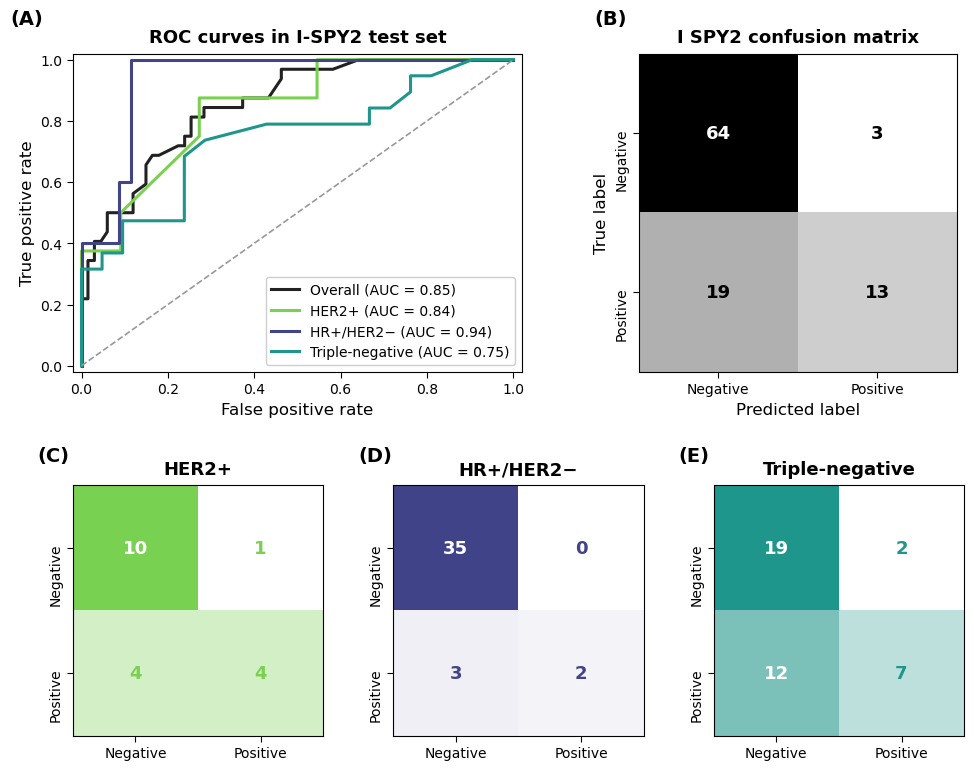

Saved: fig_6_isp2_subtypes_academic.png (277,617 bytes)
Saved: fig_6_isp2_subtypes_academic.pdf (30,321 bytes)


In [94]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# Global style for publication
# -----------------------------
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# Colors and colormaps
# (same palette as other figs)
# -----------------------------
viridis_12 = plt.cm.viridis(np.linspace(0.8, 0.2, 12))
GROUP_COLORS = [viridis_12[0], viridis_12[11], viridis_12[5]]   # green, purple, teal

cmap_overall = LinearSegmentedColormap.from_list('cm_overall', ['white', 'dimgrey', 'black'])
cmaps_group  = [LinearSegmentedColormap.from_list(f'cm_{k}', ['white', GROUP_COLORS[k]]) for k in range(3)]

THR = 0.5

# -----------------------------
# Input: I-SPY2 test set
# -----------------------------
df_test = df[(df['test'] == 1.0) & (df['dataset'] == 'spy2')].copy()

df_test['pCR'] = pd.to_numeric(df_test['pCR'], errors='coerce')
df_test['rf_pred_proba'] = pd.to_numeric(df_test['rf_pred_proba'], errors='coerce')
df_test = df_test.dropna(subset=['pCR', 'rf_pred_proba'])

y = df_test['pCR'].values
p = df_test['rf_pred_proba'].values

# -----------------------------
# Panels: overall + subtypes
# -----------------------------
panels = [
    ('__all__',      'Overall',        '#222222',       cmap_overall),
    ('HER2pos',      'HER2+',          GROUP_COLORS[0], cmaps_group[0]),
    ('HRposHER2neg', 'HR+/HER2−',      GROUP_COLORS[1], cmaps_group[1]),
    ('TripleNeg',    'Triple-negative',GROUP_COLORS[2], cmaps_group[2]),
]

# -----------------------------
# Figure layout: same as before
# -----------------------------
fig = plt.figure(figsize=(11.5, 9.2), constrained_layout=False)
outer = fig.add_gridspec(2, 1, height_ratios=[1.05, 1.0], hspace=0.28)

top    = outer[0].subgridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.28)
bottom = outer[1].subgridspec(1, 3, wspace=0.28)

ax_roc = fig.add_subplot(top[0, 0])
ax_ov  = fig.add_subplot(top[0, 1])
ax_cm1 = fig.add_subplot(bottom[0, 0])
ax_cm2 = fig.add_subplot(bottom[0, 1])
ax_cm3 = fig.add_subplot(bottom[0, 2])

cm_axes = [ax_ov, ax_cm1, ax_cm2, ax_cm3]

# -----------------------------
# Helper: panel label
# -----------------------------
def add_panel_label(ax, label):
    ax.text(
        -0.14, 1.08, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='bottom',
        ha='left'
    )

# -----------------------------
# Plot ROC + confusion matrices
# -----------------------------
for j, (key, name, color, cmap) in enumerate(panels):
    if key == '__all__':
        mask = np.ones(len(df_test), dtype=bool)
    else:
        mask = (df_test[key].values == 1)

    yj = y[mask]
    pj = p[mask]

    if mask.sum() == 0 or len(np.unique(yj)) < 2:
        print(f"Skipping {name}: empty group or single class.")
        continue

    # ROC
    fpr, tpr, _ = roc_curve(yj, pj)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=2.2,
                label=f"{name} (AUC = {roc_auc:.2f})")

    # Confusion matrix
    ax = cm_axes[j]
    yhat = (pj >= THR).astype(int)
    cm = confusion_matrix(yj, yhat)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(
        ax=ax,
        cmap=cmap,
        colorbar=False,
        values_format='d'
    )

    # Numbers and titles
    for txt in ax.texts:
        txt.set_fontsize(13)
        txt.set_fontweight('semibold')

    if key == '__all__':
        ax.set_title("I SPY2 confusion matrix", pad=8, fontweight='bold')
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
    else:
        ax.set_title(name, pad=8, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Ticks: x horizontal, y vertical
    ax.tick_params(axis='x', labelrotation=0)
    ax.tick_params(axis='y', labelrotation=90)

    ax.grid(False)
    ax.set_aspect('equal')

# -----------------------------
# Format ROC panel (same style)
# -----------------------------
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='0.6', lw=1.2)

eps = 0.02
ax_roc.set_xlim(-eps, 1 + eps)
ax_roc.set_ylim(-eps, 1 + eps)

ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curves in I-SPY2 test set", pad=8, fontweight='bold')
ax_roc.legend(loc='lower right', frameon=True, framealpha=0.95)
ax_roc.grid(False)
ax_roc.set_aspect('auto')

# -----------------------------
# Panel labels
# -----------------------------
add_panel_label(ax_roc, "(A)")
add_panel_label(ax_ov,  "(B)")
add_panel_label(ax_cm1, "(C)")
add_panel_label(ax_cm2, "(D)")
add_panel_label(ax_cm3, "(E)")

# -----------------------------
# Save
# -----------------------------
out_png = "fig_6_isp2_subtypes_academic.png"
out_pdf = "fig_6_isp2_subtypes_academic.pdf"

fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {out_png} ({os.path.getsize(out_png):,} bytes)")
print(f"Saved: {out_pdf} ({os.path.getsize(out_pdf):,} bytes)")

# random forest plotting

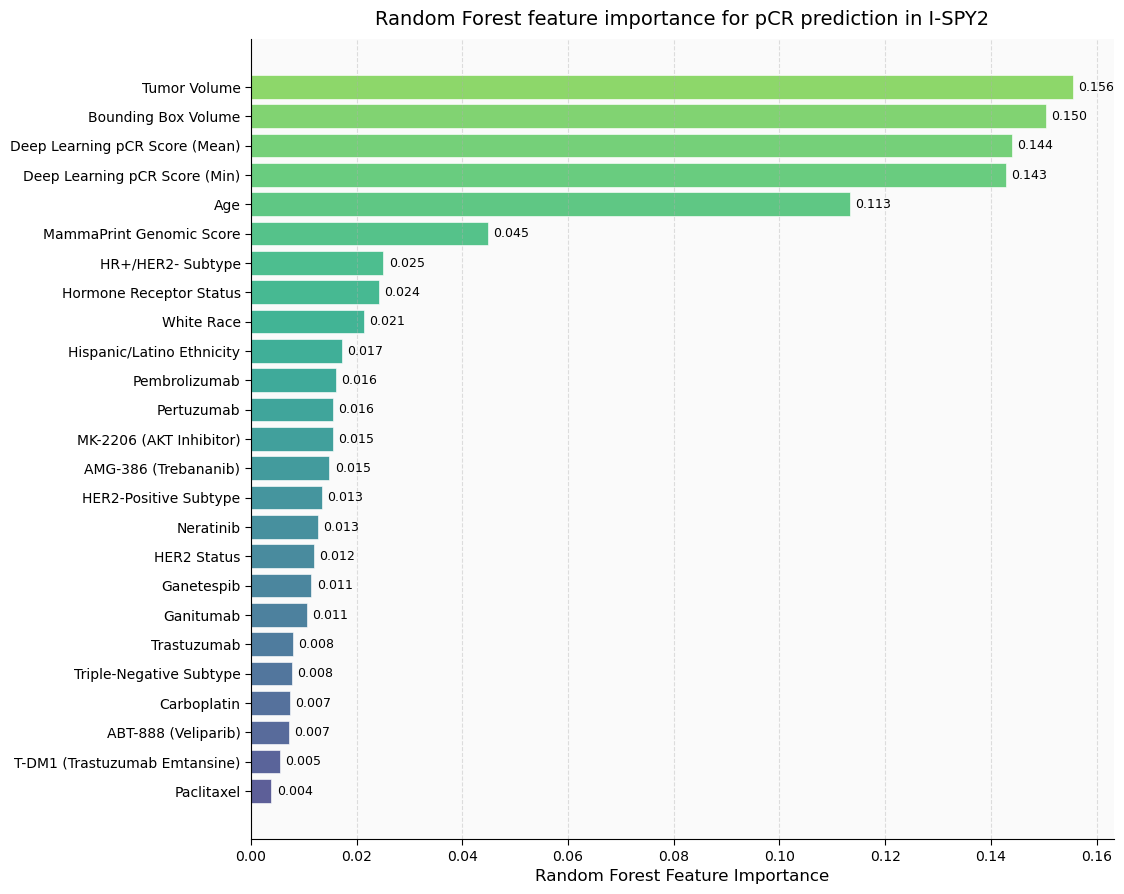

Saved: fig_7_rf_feature_importance_isp2.png (401,715 bytes)
Saved: fig_7_rf_feature_importance_isp2.pdf (18,568 bytes)


In [97]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Global style for publication
# -----------------------------
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# 1. Filter I-SPY2 data
# -----------------------------
d = df[~df.pCR.isna()][df.dataset == 'spy2']

df_test = d[d.test == 1]
df_valid = d[d.test == 2]
df_train = d[d.test == 0]
df_val_train = d[d.test != 1]

pcols = [
    'HR', 'HER2', 'MP', 'age',
    'e_hispanic_latino',
    'ABT 888', 'AMG 386', 'Carboplatin', 'Ganetespib', 'Ganitumab', 'MK-2206',
    'Neratinib', 'Paclitaxel', 'Pembrolizumab', 'Pertuzumab', 'T-DM1',
    'Trastuzumab', 'race_white',
    'HER2pos', 'HRposHER2neg', 'TripleNeg',
    'bbox_vol', 'tum_vol',
    'DL_pred_pcr_mean', 'DL_pred_pcr_min'
]

X_train = df_val_train[pcols].values
y_train = df_val_train['pCR'].values

X_test = df_test[pcols].values
y_test = df_test['pCR'].values

# -----------------------------
# 2. Standardize features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -----------------------------
# 3. Random Forest model
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
)
rf_model.fit(X_train_scaled, y_train)

rf_pred        = rf_model.predict(X_test_scaled)
rf_pred_proba  = rf_model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# 4. Publication-friendly names
# -----------------------------
feature_name_mapping = {
    # Clinical/Biomarker Features
    'HR': 'Hormone Receptor Status',
    'HER2': 'HER2 Status',
    'MP': 'MammaPrint Genomic Score',
    'age': 'Age',

    # Molecular Subtypes
    'HER2pos': 'HER2-Positive Subtype',
    'HRposHER2neg': 'HR+/HER2- Subtype',
    'TripleNeg': 'Triple-Negative Subtype',

    # Demographics
    'e_hispanic_latino': 'Hispanic/Latino Ethnicity',
    'race_white': 'White Race',

    # Treatment Agents
    'ABT 888': 'ABT-888 (Veliparib)',
    'AMG 386': 'AMG-386 (Trebananib)',
    'Carboplatin': 'Carboplatin',
    'Ganetespib': 'Ganetespib',
    'Ganitumab': 'Ganitumab',
    'MK-2206': 'MK-2206 (AKT Inhibitor)',
    'Neratinib': 'Neratinib',
    'Paclitaxel': 'Paclitaxel',
    'Pembrolizumab': 'Pembrolizumab',
    'Pertuzumab': 'Pertuzumab',
    'T-DM1': 'T-DM1 (Trastuzumab Emtansine)',
    'Trastuzumab': 'Trastuzumab',

    # Imaging / DL Features
    'bbox_vol': 'Bounding Box Volume',
    'tum_vol': 'Tumor Volume',
    'DL_pred_pcr_mean': 'Deep Learning pCR Score (Mean)',
    'DL_pred_pcr_min': 'Deep Learning pCR Score (Min)',
}

feature_names_nice = [feature_name_mapping.get(name, name) for name in pcols]

# -----------------------------
# 5. Feature importances
# -----------------------------
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names_nice,
    'importance': importances,
    'original_name': pcols,
}).sort_values('importance', ascending=True)

# -----------------------------
# 6. Plot (horizontal bar chart)
# -----------------------------
fig, ax = plt.subplots(figsize=(11.5, 9.2))  # same width as other figs, taller for many features

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df)))

y_pos = np.arange(len(importance_df))

bars = ax.barh(
    y_pos,
    importance_df['importance'].values,
    color=colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)

ax.set_yticks(y_pos)
ax.set_yticklabels(importance_df['feature'].values, fontsize=10)
ax.set_xlabel('Random Forest Feature Importance', fontsize=12)
ax.set_title('Random Forest feature importance for pCR prediction in I-SPY2',
             fontsize=14, pad=10)

# Add numeric labels to bars
for bar, importance in zip(bars, importance_df['importance'].values):
    width = bar.get_width()
    ax.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{importance:.3f}',
        ha='left',
        va='center',
        fontsize=9
    )

# Style: light x grid, no top/right spines, light background
ax.grid(axis='x', alpha=0.4, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('#fafafa')

plt.tight_layout(pad=1.5)
out_png = "fig_7_rf_feature_importance_isp2.png"
out_pdf = "fig_7_rf_feature_importance_isp2.pdf"

fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {out_png} ({os.path.getsize(out_png):,} bytes)")
print(f"Saved: {out_pdf} ({os.path.getsize(out_pdf):,} bytes)")